Upload ton fichier audio (toi) :


Saving voix_moi.mp4 to voix_moi.mp4
Fichier voix_moi.wav prêt !
Upload le fichier audio de ton ami (Nessibe) :


Saving voix_nessibe.mp4 to voix_nessibe.mp4
Fichier voix_nessibe.wav prêt !


/tmp/ipykernel_178/4069872286.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  voix_moi, sr1 = librosa.load("voix_moi.wav", sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_178/4069872286.py:34: UserWarning: PySoundFile failed. Trying audioread instead.
  voix_nessibe, sr2 = librosa.load("voix_nessibe.wav", sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


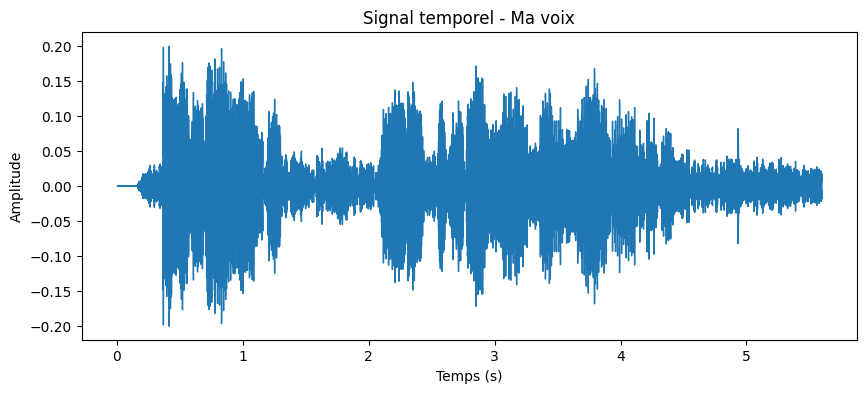

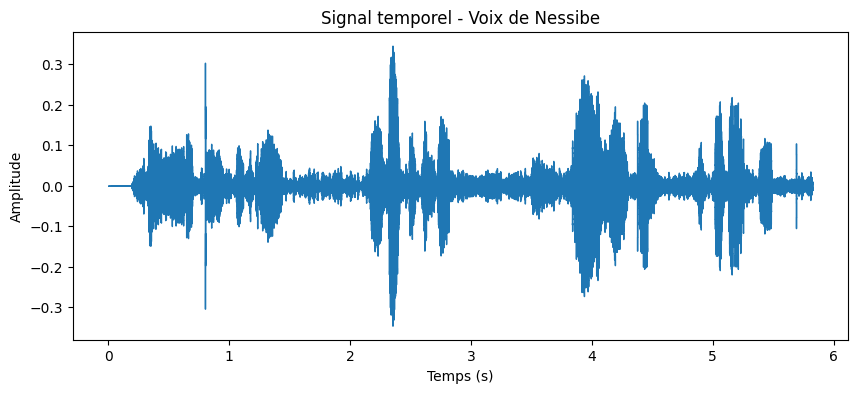

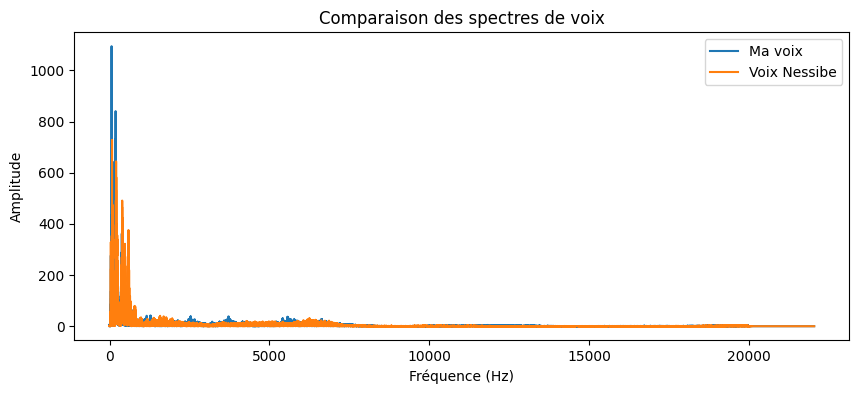

Pitch ma voix : 998.0764
Pitch voix Nessibe : 1052.6768
➡ Ma voix est plus grave
⬆️ Upload ton image bruitée (photo de nuit, .jpg ou .png) :


Saving Capture.PNG to Capture.PNG
📂 Fichier chargé : Capture.PNG


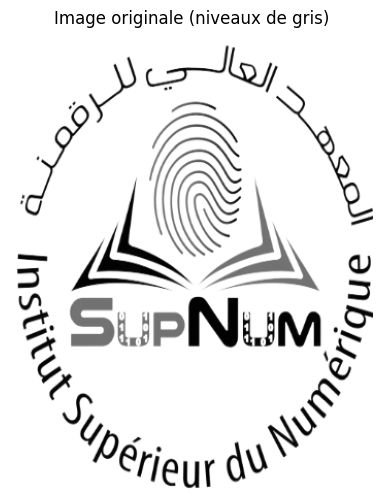

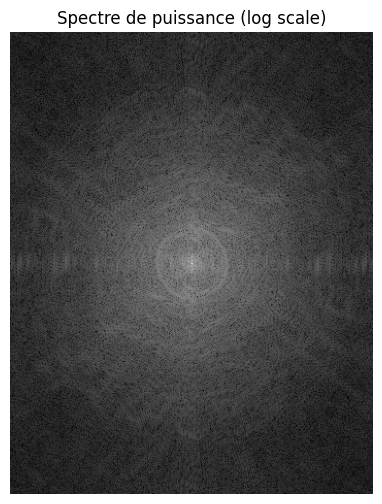

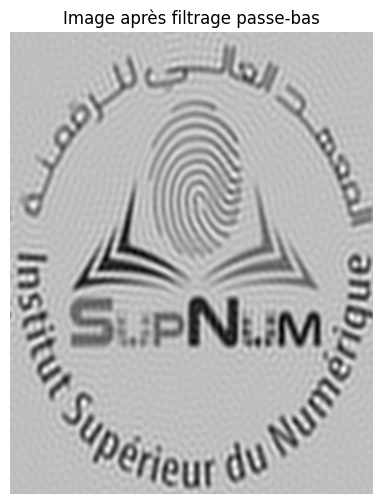

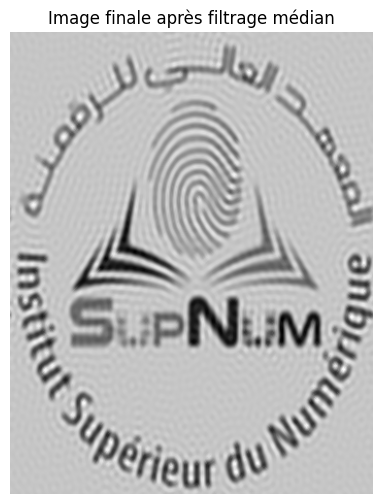

In [1]:
# --- Importer les librairies ---
from google.colab import files
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from scipy.fft import fft2, ifft2, fftshift
from scipy.ndimage import median_filter, gaussian_filter

# -------------------------------
# 1️⃣ Upload ton fichier audio (toi)
# -------------------------------
print("Upload ton fichier audio (toi) :")
uploaded = files.upload()
voix_moi_file = list(uploaded.keys())[0]
os.rename(voix_moi_file, "voix_moi.wav")
print("Fichier voix_moi.wav prêt !")

# -------------------------------
# 2️⃣ Upload fichier audio de ton ami (Nessibe)
# -------------------------------
print("Upload le fichier audio de ton ami (Nessibe) :")
uploaded = files.upload()
voix_nessibe_file = list(uploaded.keys())[0]
os.rename(voix_nessibe_file, "voix_nessibe.wav")
print("Fichier voix_nessibe.wav prêt !")

# -------------------------------
# 3️⃣ Charger les deux voix
# -------------------------------
voix_moi, sr1 = librosa.load("voix_moi.wav", sr=None, mono=True)
voix_nessibe, sr2 = librosa.load("voix_nessibe.wav", sr=None, mono=True)

# -------------------------------
# 4️⃣ Afficher les signaux temporels
# -------------------------------
plt.figure(figsize=(10,4))
librosa.display.waveshow(voix_moi, sr=sr1)
plt.title("Signal temporel - Ma voix")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(10,4))
librosa.display.waveshow(voix_nessibe, sr=sr2)
plt.title("Signal temporel - Voix de Nessibe")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.show()

# -------------------------------
# 5️⃣ Calculer FFT et superposer les spectres
# -------------------------------
fft_moi = np.fft.fft(voix_moi)
freq_moi = np.fft.fftfreq(len(fft_moi), 1/sr1)

fft_nessibe = np.fft.fft(voix_nessibe)
freq_nessibe = np.fft.fftfreq(len(fft_nessibe), 1/sr2)

plt.figure(figsize=(10,4))
plt.plot(freq_moi[:len(freq_moi)//2], np.abs(fft_moi[:len(fft_moi)//2]), label="Ma voix")
plt.plot(freq_nessibe[:len(freq_nessibe)//2], np.abs(fft_nessibe[:len(fft_nessibe)//2]), label="Voix Nessibe")
plt.title("Comparaison des spectres de voix")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# -------------------------------
# 6️⃣ Calculer le pitch moyen
# -------------------------------
pitch_moi, _ = librosa.piptrack(y=voix_moi, sr=sr1)
pitch_nessibe, _ = librosa.piptrack(y=voix_nessibe, sr=sr2)

pitch_moi_val = np.mean(pitch_moi[pitch_moi > 0])
pitch_nessibe_val = np.mean(pitch_nessibe[pitch_nessibe > 0])

print("Pitch ma voix :", pitch_moi_val)
print("Pitch voix Nessibe :", pitch_nessibe_val)

if pitch_moi_val < pitch_nessibe_val:
    print("➡ Ma voix est plus grave")
else:
    print("➡ La voix de Nessibe est plus grave")

# -------------------------------
# 7️⃣ Défi 6 : Chasseur de Fantômes (image bruitée)
# -------------------------------
print("⬆️ Upload ton image bruitée (photo de nuit, .jpg ou .png) :")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f"📂 Fichier chargé : {file_name}")

# Lecture de l'image
img_color = io.imread(file_name)

# Si image RGBA, ignorer le canal alpha
if img_color.shape[2] == 4:
    img_color = img_color[:, :, :3]

# Conversion en niveaux de gris
img_gray = color.rgb2gray(img_color)
img_gray = img_as_float(img_gray)

plt.figure(figsize=(6,6))
plt.title("Image originale (niveaux de gris)")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

# -------------------------------
# FFT 2D et spectre de puissance
# -------------------------------
F = fft2(img_gray)
F_shifted = fftshift(F)
magnitude_spectrum = np.abs(F_shifted)

plt.figure(figsize=(6,6))
plt.title("Spectre de puissance (log scale)")
plt.imshow(np.log1p(magnitude_spectrum), cmap='gray')
plt.axis('off')
plt.show()

# -------------------------------
# Filtrage passe-bas fréquentiel
# -------------------------------
rows, cols = img_gray.shape
crow, ccol = rows//2 , cols//2
radius = 50  # ajuster selon le bruit
mask = np.zeros((rows, cols))
Y, X = np.ogrid[:rows, :cols]
mask_area = (X - ccol)**2 + (Y - crow)**2 <= radius**2
mask[mask_area] = 1

F_filtered = F_shifted * mask
img_filtered = np.real(ifft2(fftshift(F_filtered)))

plt.figure(figsize=(6,6))
plt.title("Image après filtrage passe-bas")
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')
plt.show()

# -------------------------------
# Filtre médian pour réduire le bruit impulsionnel
# -------------------------------
img_final = median_filter(img_filtered, size=3)

plt.figure(figsize=(6,6))
plt.title("Image finale après filtrage médian")
plt.imshow(img_final, cmap='gray')
plt.axis('off')
plt.show()